In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:\\Users\\Pranjali\\OneDrive\\Desktop\\ml_algorithms\\linear_regression\\placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'package')

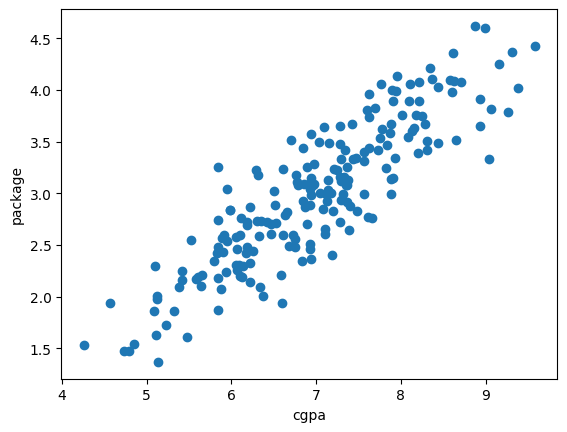

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("cgpa")
plt.ylabel("package")

In [5]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [6]:
y


0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [7]:
##train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr=LinearRegression()

In [10]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
x_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [12]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [13]:
lr.predict(x_test.iloc[1].values.reshape(1,1))

C:\Users\Pranjali\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

Text(0, 0.5, 'package')

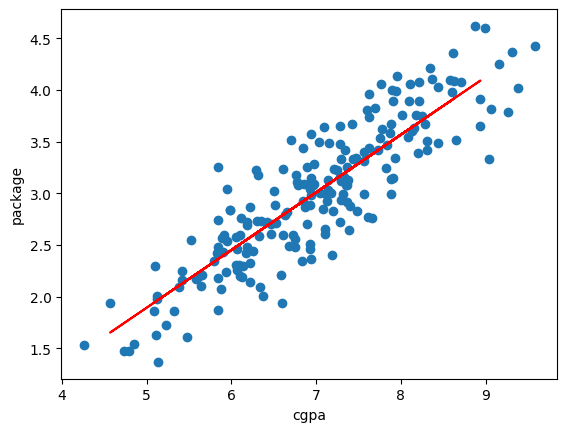

In [14]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_test,lr.predict(x_test),color="red")
plt.xlabel("cgpa")
plt.ylabel("package")

In [15]:
m=lr.coef_

In [16]:
b=lr.intercept_

In [17]:
### so in equation of line the code actually first find the value for m and b and then put the value of x in it and then predictedthe y
m*8.58 + b
## so this is the predicted package for the given cgpa as mentioned in above x_test and y_test

array([3.89111601])

In [18]:
# taking any cgpa value
m*9.98+ b

array([4.67224877])

In [19]:
## regression metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [20]:
y_pred=lr.predict(x_test)

In [21]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

MAE is average prediction errros(how much my model is wrong on average)

In [22]:
print("MAE",mean_absolute_error(y_test,y_pred))   ### mae tells the average errors your model is making 

MAE 0.2884710931878175


the mae tells that the lpa prediction differes by 0.28  lpa i.e 28,000

MSE peanlty for lrage errors lower is etter but not used to interpret the original units

In [23]:
print("MSE",mean_squared_error(y_test,y_pred))
##

MSE 0.12129235313495527


RMSE avg prediction errors with extra penality for large mistakes(it gives much more impoartance to large mistakes)

In [24]:
print("rMSE",root_mean_squared_error(y_test,y_pred))
##mae  near to rmse so your model is good fro doing the predictrions

rMSE 0.34827051717731616


In [25]:
print("R2 SCORE",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)

R2 SCORE 0.780730147510384


In [26]:
x_test.shape

(40, 1)

In [27]:
##adjusted r2 score
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415